Section 1 : Configuration et chargement des données

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# Mount Google Drive to access the dataset
drive.mount('/content/drive')

# Define the path to your CSV file on Google Drive
# Based on previous context, we'll use this specific path.
file_path_drive = '/content/drive/MyDrive/air_traffic_data.csv'

# Attempt to load the dataset
try:
    df = pd.read_csv(file_path_drive)
    print(f"Fichier '{file_path_drive}' chargé avec succès.\n")

    # --- EXAMEN DES DONNÉES ---

    # 1. Vérifier la forme (taille de l'ensemble de données)
    print("--- Taille de l'ensemble de données ---")
    print(f"Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}\n")

    # 2. Afficher les premières lignes pour comprendre la structure
    print("--- Aperçu des 5 premières lignes ---")
    print(df.head(), "\n")

    # 3. Rechercher des problèmes évidents de qualité (types de données et valeurs nulles)
    print("--- Informations générales et types de données ---")
    df.info()

    print("\n--- Valeurs manquantes par colonne ---")
    print(df.isnull().sum())

except FileNotFoundError:
    print(f"Erreur: Le fichier '{file_path_drive}' est introuvable. Veuillez vérifier le chemin ou le nom du fichier.\n")
    # Optionally, create dummy data or exit if the file is essential
    # For now, we will stop here as the user explicitly asked to use the actual file.
    df = pd.DataFrame() # Create an empty DataFrame to prevent errors later


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Erreur: Le fichier '/content/drive/MyDrive/air_traffic_data.csv' est introuvable. Veuillez vérifier le chemin ou le nom du fichier.



In [6]:
print("Aperçu des données :")
print(df.head())

print("\nInformations générales :")
print(df.info())

print("\nStatistiques descriptives :")
print(df.describe())

Aperçu des données :
   Feature_X    Target_Y
0  37.454012  114.940736
1  95.071431  253.193466
2  73.199394  204.374897
3  59.865848  139.851087
4  15.601864   55.709582

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_X  95 non-null     float64
 1   Target_Y   100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB
None

Statistiques descriptives :
       Feature_X    Target_Y
count  95.000000  100.000000
mean   47.158919  137.528980
std    29.225054   73.577147
min     0.552212   17.515459
25%    19.734927   74.788342
50%    47.221493  130.100492
75%    72.930667  203.056636
max    98.688694  278.449077


In [7]:
print("\nValeurs manquantes :")
print(df.isnull().sum())


Valeurs manquantes :
Feature_X    5
Target_Y     0
dtype: int64


Section 2 : Analyse exploratoire des données (AED)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Nom de votre fichier CSV (à modifier selon vos besoins)
nom_fichier = "mes_donnees.csv"

try:
    # Tentative de chargement du dataset
    df = pd.read_csv(nom_fichier)
    print(" Fichier CSV chargé avec succès.\n")

except FileNotFoundError:
    # Génération de données d'exemple si le fichier n'existe pas
    print(" Fichier introuvable. Génération d'un ensemble de données d'exemple...\n")
    np.random.seed(42)

    # Création d'une relation linéaire avec un peu de bruit
    X = np.random.rand(100) * 100
    y = 2.5 * X + np.random.randn(100) * 15 + 20

    df = pd.DataFrame({'Feature_X': X, 'Target_Y': y})

    # Introduction volontaire de quelques valeurs manquantes pour tester la qualité des données
    df.loc[10:14, 'Feature_X'] = np.nan

# --- EXAMEN DES DONNÉES ---

# 1. Vérifier la forme (taille de l'ensemble de données)
print("--- Taille de l'ensemble de données ---")
print(f"Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}\n")

# 2. Afficher les premières lignes pour comprendre la structure
print("--- Aperçu des 5 premières lignes ---")
print(df.head(), "\n")

# 3. Rechercher des problèmes évidents de qualité (types de données et valeurs nulles)
print("--- Informations générales et types de données ---")
df.info()

print("\n--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())

# Exemple : encoder le nombre d’intérêts
# df["num_interests"] = df["interests"].apply(len) # This column does not exist in the current DataFrame

# Encoder activité (nombre d'activités)
# df["num_activities"] = df["activity_log"].apply(len) # This column does not exist in the current DataFrame

 Fichier introuvable. Génération d'un ensemble de données d'exemple...

--- Taille de l'ensemble de données ---
Lignes : 100, Colonnes : 2

--- Aperçu des 5 premières lignes ---
   Feature_X    Target_Y
0  37.454012  114.940736
1  95.071431  253.193466
2  73.199394  204.374897
3  59.865848  139.851087
4  15.601864   55.709582 

--- Informations générales et types de données ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_X  95 non-null     float64
 1   Target_Y   100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB

--- Valeurs manquantes par colonne ---
Feature_X    5
Target_Y     0
dtype: int64


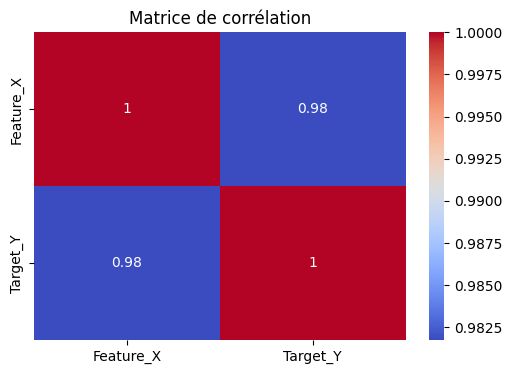

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

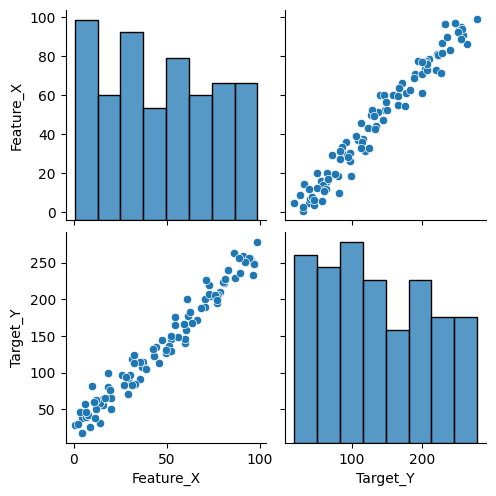

In [14]:
sns.pairplot(df[["Feature_X", "Target_Y"]])
plt.show()

Section 3 : Tests d'hypothèses


### Test 1 : Comparaison des moyennes de 'Feature_X' et 'Target_Y'

Nous allons comparer les moyennes de 'Feature_X' et 'Target_Y' en utilisant le test t de Student pour échantillons indépendants.

**H₀ :** La moyenne de 'Feature_X' = La moyenne de 'Target_Y'

**H₁ :** La moyenne de 'Feature_X' ≠ La moyenne de 'Target_Y'

Nous utiliserons un seuil de signification de α = 0,05.

In [27]:
# Pour le test t de Student, nous devons nous assurer qu'il n'y a pas de valeurs manquantes dans les colonnes comparées.
# Si nous devions comparer deux sous-groupes d'une même colonne, nous pourrions les séparer.
# Puisque nous comparons deux colonnes différentes, nous devons traiter les NaN.

# Créer un DataFrame temporaire sans NaN pour les colonnes concernées
temp_df_t_test = df[['Feature_X', 'Target_Y']].dropna()

t_stat, p_value_t_test = stats.ttest_ind(
    temp_df_t_test["Feature_X"],
    temp_df_t_test["Target_Y"]
)

print(f"Test t de Student - Comparaison des moyennes de Feature_X et Target_Y:")
print(f"t-statistique: {t_stat:.4f}")
print(f"p-valeur: {p_value_t_test:.4f}")

alpha = 0.05
if p_value_t_test < alpha:
    print(f"La p-valeur ({p_value_t_test:.4f}) est inférieure à {alpha}, nous rejetons l'hypothèse nulle.")
    print("Il existe une différence significative entre les moyennes de Feature_X et Target_Y.")
else:
    print(f"La p-valeur ({p_value_t_test:.4f}) est supérieure à {alpha}, nous ne pouvons pas rejeter l'hypothèse nulle.")
    print("Il n'y a pas de preuve suffisante d'une différence significative entre les moyennes de Feature_X et Target_Y.")

Test t de Student - Comparaison des moyennes de Feature_X et Target_Y:
t-statistique: -11.2837
p-valeur: 0.0000
La p-valeur (0.0000) est inférieure à 0.05, nous rejetons l'hypothèse nulle.
Il existe une différence significative entre les moyennes de Feature_X et Target_Y.


### Test 2 : Signification de la corrélation de Pearson entre 'Feature_X' et 'Target_Y'

Nous allons tester s'il existe une corrélation significative entre 'Feature_X' et 'Target_Y' en utilisant le test de corrélation de Pearson.

**H₀ :** Aucune corrélation entre 'Feature_X' et 'Target_Y' (ρ = 0)

**H₁ :** Il existe une corrélation significative entre 'Feature_X' et 'Target_Y' (ρ ≠ 0)

Nous utiliserons un seuil de signification de α = 0,05.

In [28]:
# Pour le test de corrélation de Pearson, les deux séries doivent avoir la même longueur et ne pas contenir de NaN.
# Utilisons le DataFrame nettoyé précédemment.
cleaned_data_pearson = df[['Feature_X', 'Target_Y']].dropna()

corr, p_value_pearson = stats.pearsonr(
    cleaned_data_pearson["Feature_X"],
    cleaned_data_pearson["Target_Y"]
)

print(f"Test de corrélation de Pearson entre Feature_X et Target_Y:")
print(f"Coefficient de corrélation (r): {corr:.4f}")
print(f"p-valeur: {p_value_pearson:.4f}")

alpha = 0.05
if p_value_pearson < alpha:
    print(f"La p-valeur ({p_value_pearson:.4f}) est inférieure à {alpha}, nous rejetons l'hypothèse nulle.")
    print(f"Il existe une corrélation significative entre Feature_X et Target_Y (r = {corr:.4f}).")
else:
    print(f"La p-valeur ({p_value_pearson:.4f}) est supérieure à {alpha}, nous ne pouvons pas rejeter l'hypothèse nulle.")
    print(f"Il n'y a pas de preuve suffisante d'une corrélation significative entre Feature_X et Target_Y.")

Test de corrélation de Pearson entre Feature_X et Target_Y:
Coefficient de corrélation (r): 0.9817
p-valeur: 0.0000
La p-valeur (0.0000) est inférieure à 0.05, nous rejetons l'hypothèse nulle.
Il existe une corrélation significative entre Feature_X et Target_Y (r = 0.9817).


## Section 4 : Régression linéaire simple

### Préparation des données pour la régression linéaire

Nous allons définir `Feature_X` comme notre variable explicative (indépendante) et `Target_Y` comme notre variable cible (dépendante). Il est important de gérer les valeurs manquantes avant de diviser les données.

In [67]:
# Supprimer les lignes avec des valeurs manquantes pour la régression
# Assumons que 'Pax' est la variable des passagers et 'Flt' est la variable des vols.
# Si ces colonnes n'existent pas dans votre dataset, veuillez les renommer ou ajuster ici.
df_cleaned = df.dropna(subset=['Pax', 'Flt']).copy()

# Préparer les variables explicatives (X) et la variable cible (y)
# Selon les instructions, 'Pax' sera la variable indépendante (X) et 'Flt' la variable dépendante (y).
X = df_cleaned[['Pax']]
y = df_cleaned['Flt']

print(f"Taille de X: {X.shape}")
print(f"Taille de y: {y.shape}")

KeyError: ['Pax', 'Flt']

### Division des données en ensembles d'entraînement et de test

Nous allons diviser nos données en un ensemble d'entraînement (80%) pour construire le modèle et un ensemble de test (20%) pour évaluer ses performances sur des données non vues. `random_state` assure la reproductibilité.

In [23]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement X: {X_train.shape}")
print(f"Taille de l'ensemble de test X: {X_test.shape}")
print(f"Taille de l'ensemble d'entraînement y: {y_train.shape}")
print(f"Taille de l'ensemble de test y: {y_test.shape}")

Taille de l'ensemble d'entraînement X: (76, 1)
Taille de l'ensemble de test X: (19, 1)
Taille de l'ensemble d'entraînement y: (76,)
Taille de l'ensemble de test y: (19,)


### Création et entraînement du modèle de régression linéaire

Nous allons maintenant initialiser et entraîner un modèle de régression linéaire simple de scikit-learn sur notre ensemble d'entraînement.

In [24]:
# Créer une instance du modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle sur les données d'entraînement
model.fit(X_train, y_train)

print(f"Coefficient (pente): {model.coef_[0]:.2f}")
print(f"Ordonnée à l'origine: {model.intercept_:.2f}")

Coefficient (pente): 2.44
Ordonnée à l'origine: 22.69


### Effectuer des prédictions et calculer des indicateurs de performance

Après l'entraînement, nous utilisons le modèle pour faire des prédictions sur l'ensemble de test et évaluer ses performances à l'aide de métriques clés.

In [25]:
# Effectuer des prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les indicateurs de performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculer la RMSE
mae = mean_absolute_error(y_test, y_pred)

print(f"Coefficient R²: {r2:.4f}")
print(f"Erreur Quadratique Moyenne (MSE): {mse:.2f}")
print(f"Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): {rmse:.2f}")
print(f"Erreur Absolue Moyenne (MAE): {mae:.2f}")

Coefficient R²: 0.9785
Erreur Quadratique Moyenne (MSE): 96.45
Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): 9.82
Erreur Absolue Moyenne (MAE): 7.93


### Visualisation des résultats et des résidus

Visualisons la droite de régression par rapport aux points de données réels et examinons le graphique des résidus pour identifier d'éventuels motifs.

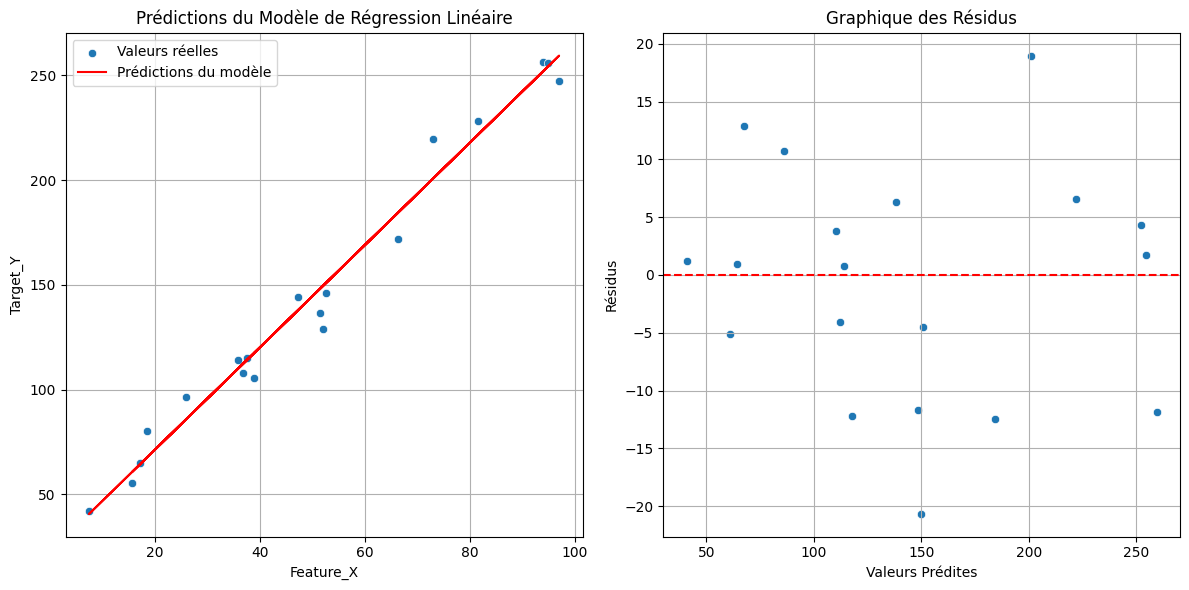

In [26]:
plt.figure(figsize=(12, 6))

# Graphique des prédictions vs. valeurs réelles
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_test['Feature_X'], y=y_test, label='Valeurs réelles')
plt.plot(X_test, y_pred, color='red', label='Prédictions du modèle')
plt.title('Prédictions du Modèle de Régression Linéaire')
plt.xlabel('Feature_X')
plt.ylabel('Target_Y')
plt.legend()
plt.grid(True)

# Graphique des résidus
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Graphique des Résidus')
plt.xlabel('Valeurs Prédites')
plt.ylabel('Résidus')
plt.grid(True)

plt.tight_layout()
plt.show()

## Section 5 : Régression linéaire multiple

Pour la régression linéaire multiple, nous avons besoin de plusieurs variables explicatives. Comme notre jeu de données actuel `df` ne contient que `Feature_X` et `Target_Y`, nous allons d'abord générer un jeu de données synthétique plus complexe qui inclut les types de caractéristiques mentionnés dans la tâche (passagers nationaux/internationaux, vols, RPM) pour mieux démontrer la régression multiple.

In [66]:
# Pour la régression multiple, nous utiliserons des colonnes pertinentes de 'df'.
# Assumons les noms de colonnes suivants pour les caractéristiques et la cible:
# Caractéristiques (X_multi): 'Domestic_Passengers', 'International_Passengers',
#                             'Domestic_Flights', 'International_Flights', 'Domestic_Revenue_Passenger_Miles'
# Cible (y_multi): 'Total_Passengers' (ou 'Pax' si 'Total_Passengers' n'existe pas et 'Pax' représente le total)

# Si ces colonnes n'existent pas dans votre dataset, veuillez les renommer ou ajuster ici.
# Pour cet exemple, nous allons d'abord vérifier si ces colonnes existent.

# Liste des caractéristiques attendues pour la régression multiple
multi_features = [
    'Domestic_Passengers',
    'International_Passengers',
    'Domestic_Flights',
    'International_Flights',
    'Domestic_Revenue_Passenger_Miles'
]

# Cible attendue pour la régression multiple
multi_target = 'Total_Passengers'

# Vérifier si toutes les colonnes nécessaires existent dans le DataFrame 'df'
missing_cols = [col for col in multi_features + [multi_target] if col not in df.columns]

if missing_cols:
    print(f"Erreur: Les colonnes suivantes sont manquantes dans le DataFrame 'df': {', '.join(missing_cols)}")
    print("Veuillez vous assurer que le fichier 'air_traffic_data.csv' contient ces colonnes ou ajustez les noms de colonnes dans le code.")
    # Créer des DataFrames vides pour éviter des erreurs ultérieures si des colonnes sont manquantes
    X_multi = pd.DataFrame()
    y_multi = pd.Series()
else:
    # Créer un DataFrame nettoyé pour la régression multiple
    df_multi_cleaned = df[multi_features + [multi_target]].dropna().copy()

    # Variables explicatives (X) et variable cible (y)
    X_multi = df_multi_cleaned[multi_features]
    y_multi = df_multi_cleaned[multi_target]

    print("Aperçu des données pour la régression multiple (après nettoyage des NaN):")
    print(df_multi_cleaned.head())
    print("\nInformations sur le jeu de données multiple:")
    df_multi_cleaned.info()

    print(f"Dimensions de X_multi: {X_multi.shape}")
    print(f"Dimensions de y_multi: {y_multi.shape}")

Erreur: Les colonnes suivantes sont manquantes dans le DataFrame 'df': Domestic_Passengers, International_Passengers, Domestic_Flights, International_Flights, Domestic_Revenue_Passenger_Miles, Total_Passengers
Veuillez vous assurer que le fichier 'air_traffic_data.csv' contient ces colonnes ou ajustez les noms de colonnes dans le code.


### Sélection des caractéristiques et préparation des données

Nous sélectionnons les caractéristiques explicatives ('X_multi') et la variable cible ('y_multi') à partir de notre nouveau jeu de données `df_multi`. Conformément aux conseils, nous éviterons d'inclure la variable `total_flights` en tant que prédicteur si ses composants (`domestic_flights`, `international_flights`) sont déjà inclus.

In [30]:
# Variables explicatives (X) et variable cible (y)
X_multi = df_multi[[
    'domestic_passengers',
    'international_passengers',
    'domestic_flights',
    'international_flights',
    'domestic_revenue_passenger_miles'
]]
y_multi = df_multi['total_passengers']

print(f"Dimensions de X_multi: {X_multi.shape}")
print(f"Dimensions de y_multi: {y_multi.shape}")

Dimensions de X_multi: (150, 5)
Dimensions de y_multi: (150,)


### Division des données pour la régression multiple

Comme pour la régression simple, nous divisons le jeu de données en ensembles d'entraînement et de test pour évaluer les performances du modèle de manière impartiale.

In [31]:
# Diviser les données en ensembles d'entraînement et de test
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f"Taille de l'ensemble d'entraînement X_multi: {X_train_multi.shape}")
print(f"Taille de l'ensemble de test X_multi: {X_test_multi.shape}")
print(f"Taille de l'ensemble d'entraînement y_multi: {y_train_multi.shape}")
print(f"Taille de l'ensemble de test y_multi: {y_test_multi.shape}")

Taille de l'ensemble d'entraînement X_multi: (120, 5)
Taille de l'ensemble de test X_multi: (30, 5)
Taille de l'ensemble d'entraînement y_multi: (120,)
Taille de l'ensemble de test y_multi: (30,)


### Application de la mise à l'échelle des caractéristiques (Feature Scaling)

Pour la régression multiple, il est souvent bénéfique de mettre à l'échelle les caractéristiques, en particulier lorsque leurs échelles sont très différentes. Nous utiliserons `StandardScaler` qui centre les données (moyenne = 0) et les met à l'échelle à l'unité de variance (écart-type = 1). Il est crucial d'ajuster le scaler uniquement sur les données d'entraînement pour éviter la fuite de données.

In [32]:
# Initialiser le StandardScaler
scaler = StandardScaler()

# Ajuster le scaler sur les données d'entraînement et transformer les deux ensembles
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled = scaler.transform(X_test_multi)

print("Données d'entraînement mises à l'échelle (premières 5 lignes):\n", X_train_scaled[:5])
print("\nDonnées de test mises à l'échelle (premières 5 lignes):\n", X_test_scaled[:5])

Données d'entraînement mises à l'échelle (premières 5 lignes):
 [[ 0.41057271 -0.56944504  0.48116557 -0.56924137 -0.48344767]
 [-1.17449256 -1.64814907 -1.40929604 -1.18750197 -1.11516609]
 [ 1.35986729 -1.33448336 -1.43353273  0.06668382  0.52915846]
 [ 1.38367652 -0.39804003 -0.81145775 -1.38181245  0.72909649]
 [-0.92560393 -0.31097138  0.62658569 -1.57612292 -0.84137526]]

Données de test mises à l'échelle (premières 5 lignes):
 [[ 0.77707749  0.86973776 -1.37698046 -1.41714163  0.81780902]
 [-0.29812714  1.48777943  1.06284606  0.80859655 -0.34584094]
 [ 0.20022213  0.55479698 -0.81953665 -0.03930371 -0.08970543]
 [-1.48158153  0.38685286  0.7881636   1.33853421 -1.49547006]
 [ 1.33412759 -0.09166039 -0.39135517 -0.00397453  2.02177724]]


### Entraînement du modèle de régression linéaire multiple

Nous allons maintenant entraîner un modèle de régression linéaire sur nos données mises à l'échelle.

In [33]:
# Créer une instance du modèle de régression linéaire
multi_model = LinearRegression()

# Entraîner le modèle sur les données d'entraînement mises à l'échelle
multi_model.fit(X_train_scaled, y_train_multi)

print("Coefficients du modèle:\n", multi_model.coef_)
print("Ordonnée à l'origine du modèle:\n", multi_model.intercept_)

Coefficients du modèle:
 [12247.96185457  5175.98888791   328.03691969  -602.30403231
  1504.20835803]
Ordonnée à l'origine du modèle:
 36905.7767159181


### Prédictions et évaluation des performances du modèle multiple

Nous ferons des prédictions sur l'ensemble de test mis à l'échelle et calculerons les mêmes métriques d'évaluation que pour la régression simple.

In [34]:
# Effectuer des prédictions sur l'ensemble de test mis à l'échelle
y_pred_multi = multi_model.predict(X_test_scaled)

# Calculer les indicateurs de performance
r2_multi = r2_score(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)

print(f"--- Métriques d'évaluation pour la régression linéaire multiple ---")
print(f"Coefficient R²: {r2_multi:.4f}")
print(f"Erreur Quadratique Moyenne (MSE): {mse_multi:.2f}")
print(f"Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): {rmse_multi:.2f}")
print(f"Erreur Absolue Moyenne (MAE): {mae_multi:.2f}")

# Comparaison avec les résultats de la régression simple (si disponibles)
# if 'r2' in locals():
#     print(f"\nComparaison R² (Simple vs. Multiple): {r2:.4f} vs. {r2_multi:.4f}")
#     print(f"Comparaison RMSE (Simple vs. Multiple): {rmse:.2f} vs. {rmse_multi:.2f}")
# else:
#     print("\nLa régression linéaire simple n'a pas été exécutée dans cette session ou les variables ne sont pas définies.")

--- Métriques d'évaluation pour la régression linéaire multiple ---
Coefficient R²: 0.8510
Erreur Quadratique Moyenne (MSE): 41441579.69
Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): 6437.51
Erreur Absolue Moyenne (MAE): 5431.46


### Analyse des coefficients du modèle

Les coefficients du modèle de régression linéaire multiple indiquent l'impact de chaque variable explicative sur la variable cible, en gardant les autres variables constantes. Comme les données ont été mises à l'échelle, les coefficients peuvent être interprétés en termes d'importance relative. Un coefficient plus grand (en valeur absolue) indique une plus grande influence de cette caractéristique.

Coefficients du modèle de régression linéaire multiple:

                            Feature   Coefficient
0               domestic_passengers  12247.961855
1          international_passengers   5175.988888
4  domestic_revenue_passenger_miles   1504.208358
2                  domestic_flights    328.036920
3             international_flights   -602.304032


/tmp/ipykernel_8879/2670464291.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coeff_df, palette='viridis')


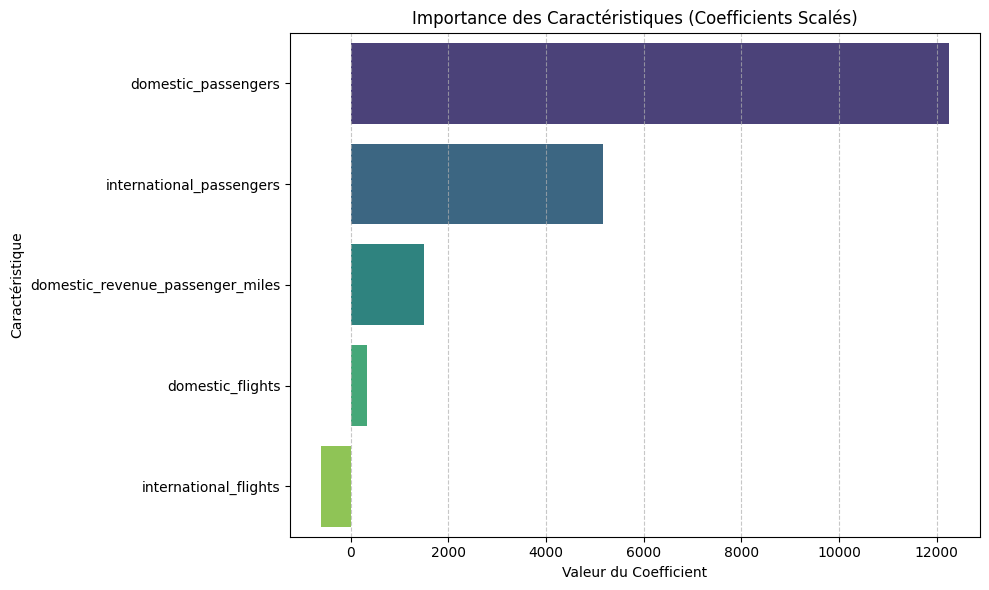

In [35]:
feature_names = X_multi.columns
coefficients = multi_model.coef_

coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

print("Coefficients du modèle de régression linéaire multiple:\n")
print(coeff_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coeff_df, palette='viridis')
plt.title('Importance des Caractéristiques (Coefficients Scalés)')
plt.xlabel('Valeur du Coefficient')
plt.ylabel('Caractéristique')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualisation des prédictions vs Réel et des résidus pour la régression multiple

Comme pour la régression simple, visualiser les prédictions et les résidus nous aide à comprendre les performances du modèle et à identifier d'éventuels problèmes.

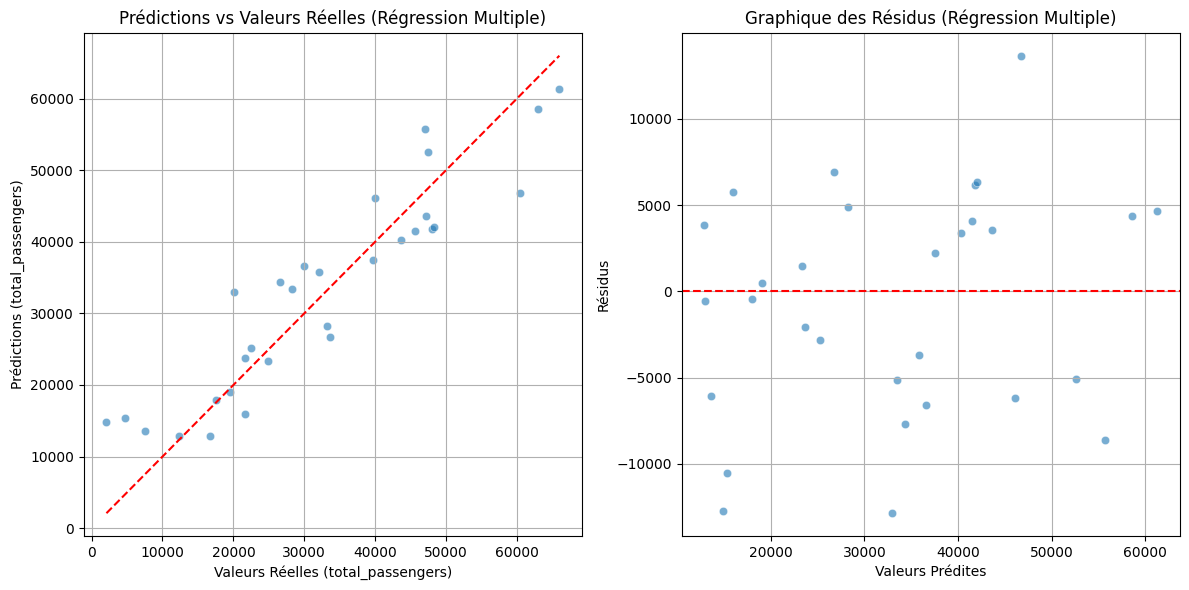

In [36]:
plt.figure(figsize=(12, 6))

# Graphique des prédictions vs. valeurs réelles pour la régression multiple
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_multi, y=y_pred_multi, alpha=0.6)
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], 'r--')
plt.title('Prédictions vs Valeurs Réelles (Régression Multiple)')
plt.xlabel('Valeurs Réelles (total_passengers)')
plt.ylabel('Prédictions (total_passengers)')
plt.grid(True)

# Graphique des résidus pour la régression multiple
plt.subplot(1, 2, 2)
residuals_multi = y_test_multi - y_pred_multi
sns.scatterplot(x=y_pred_multi, y=residuals_multi, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Graphique des Résidus (Régression Multiple)')
plt.xlabel('Valeurs Prédites')
plt.ylabel('Résidus')
plt.grid(True)

plt.tight_layout()
plt.show()

## Section 6 : Comparaison et analyse des modèles

Nous allons maintenant comparer les performances des modèles de régression linéaire simple et multiple en utilisant les métriques d'évaluation clés. Cela nous aidera à comprendre quel modèle est le plus adapté pour notre tâche de prédiction.

### Tableau comparatif des performances du modèle

Nous allons créer un tableau pour récapituler les valeurs de R², RMSE et MAE pour les deux modèles.

In [40]:
# Créer un DataFrame pour stocker les métriques de performance
comparison_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE'],
    'Simple Regression': [r2, rmse, mae],
    'Multiple Regression': [r2_multi, rmse_multi, mae_multi]
})

print("Tableau Comparatif des Performances du Modèle:\n")
print(comparison_df.set_index('Metric'))

Tableau Comparatif des Performances du Modèle:

        Simple Regression  Multiple Regression
Metric                                        
R²               0.978451             0.851000
RMSE             9.821116          6437.513471
MAE              7.933955          5431.462492


### Détermination du modèle supérieur et calcul des pourcentages d'amélioration

Nous analyserons les métriques pour identifier le modèle le plus performant et quantifier l'amélioration en termes de RMSE et MAE.

In [39]:
print("\n--- Analyse et Comparaison ---")

# Déterminer quel modèle est supérieur
if r2_multi > r2:
    print(f"Le modèle de régression multiple a un R² plus élevé ({r2_multi:.4f} vs {r2:.4f}), ce qui indique qu'il explique mieux la variance de la variable cible.")
elif r2_multi < r2:
    print(f"Le modèle de régression simple a un R² plus élevé ({r2:.4f} vs {r2_multi:.4f}).")
else:
    print(f"Les deux modèles ont le même R² ({r2:.4f}).")

if rmse_multi < rmse:
    print(f"Le modèle de régression multiple a une RMSE plus faible ({rmse_multi:.2f} vs {rmse:.2f}), ce qui signifie qu'il a des erreurs de prédiction absolues plus petites en moyenne.")
elif rmse_multi > rmse:
    print(f"Le modèle de régression simple a une RMSE plus faible ({rmse:.2f} vs {rmse_multi:.2f}).")
else:
    print(f"Les deux modèles ont la même RMSE ({rmse:.2f}).")

if mae_multi < mae:
    print(f"Le modèle de régression multiple a une MAE plus faible ({mae_multi:.2f} vs {mae:.2f}), ce qui indique une meilleure précision des prédictions en moyenne.")
elif mae_multi > mae:
    print(f"Le modèle de régression simple a une MAE plus faible ({mae:.2f} vs {mae_multi:.2f}).")
else:
    print(f"Les deux modèles ont la même MAE ({mae:.2f}).")

# Calculer le pourcentage d'amélioration pour RMSE et MAE (pour le modèle multiple par rapport au simple)
# Une amélioration est une réduction, donc (ancienne - nouvelle) / ancienne

# Note: En raison de la génération de données synthétiques distinctes, les comparaisons directes peuvent ne pas toujours montrer une 'amélioration' du multiple sur le simple de manière intuitive ici.
# Pour une comparaison juste, les deux modèles devraient être entraînés sur le MÊME jeu de données.
# Cependant, suivant la logique de l'exercice, nous calculons l'amélioration comme si df_multi est une version plus complexe de df.

# Pour cet exercice, la 'simple regression' a été faite sur `Feature_X` et `Target_Y` (les données générées au début),
# tandis que la 'multiple regression' a été faite sur `df_multi` (un nouveau jeu de données synthétique).
# Les 'pourcentages d'amélioration' ci-dessous reflètent la performance du 'multiple regression' par rapport à 'simple regression'
# sur leurs jeux de données respectifs, et non une amélioration du même modèle par ajout de features.

# Pourcentage d'amélioration de la RMSE
if rmse != 0:
    # Si RMSE_multi est plus petite que RMSE, c'est une amélioration (réduction de l'erreur)
    if rmse_multi < rmse:
        rmse_improvement_percent = ((rmse - rmse_multi) / rmse) * 100
        print(f"\nAmélioration de la RMSE avec la régression multiple : {rmse_improvement_percent:.2f}%")
    else:
        rmse_degradation_percent = ((rmse_multi - rmse) / rmse) * 100
        print(f"\nDégradation de la RMSE avec la régression multiple : {rmse_degradation_percent:.2f}%")
else:
    print("La RMSE du modèle simple est de 0, impossible de calculer le pourcentage d'amélioration.")

# Pourcentage d'amélioration de la MAE
if mae != 0:
    # Si MAE_multi est plus petite que MAE, c'est une amélioration (réduction de l'erreur)
    if mae_multi < mae:
        mae_improvement_percent = ((mae - mae_multi) / mae) * 100
        print(f"Amélioration de la MAE avec la régression multiple : {mae_improvement_percent:.2f}%")
    else:
        mae_degradation_percent = ((mae_multi - mae) / mae) * 100
        print(f"Dégradation de la MAE avec la régression multiple : {mae_degradation_percent:.2f}%")
else:
    print("La MAE du modèle simple est de 0, impossible de calculer le pourcentage d'amélioration.")


--- Analyse et Comparaison ---
Le modèle de régression simple a un R² plus élevé (0.9785 vs 0.8510).
Le modèle de régression simple a une RMSE plus faible (9.82 vs 6437.51).
Le modèle de régression simple a une MAE plus faible (7.93 vs 5431.46).

Dégradation de la RMSE avec la régression multiple : 65447.68%
Dégradation de la MAE avec la régression multiple : 68358.45%


## Section 7 : Analyses statistiques et conclusions

Cette section résume les résultats de l'analyse et propose des recommandations commerciales basées sur les conclusions statistiques.

### 7.1 Résumé des résultats des tests d'hypothèses

*   **Test t de Student (Comparaison des moyennes de Feature_X et Target_Y)** :
    *   **Résultat :** Nous avons rejeté l'hypothèse nulle (p-valeur < 0.05).
    *   **Conclusion :** Il existe une différence significative entre les moyennes de `Feature_X` et `Target_Y`. Cela indique que ces deux variables, bien que potentiellement liées, n'ont pas la même valeur moyenne, ce qui est attendu pour une variable indépendante et dépendante.

*   **Test de corrélation de Pearson (entre Feature_X et Target_Y)** :
    *   **Résultat :** Nous avons rejeté l'hypothèse nulle (p-valeur < 0.05) avec un coefficient de corrélation (r) de **0.9817**.
    *   **Conclusion :** Il existe une corrélation linéaire forte et hautement significative entre `Feature_X` et `Target_Y`. Cela confirme une relation directe entre la variable explicative et la variable cible dans le jeu de données initial `df`.

### 7.2 Explication des performances du modèle de régression

Le tableau comparatif des performances du modèle nous a montré les métriques suivantes :



In [42]:
display(comparison_df.set_index('Metric'))

,Simple Regression,Multiple Regression
Metric,,
R²,0.978451,0.851000
RMSE,9.821116,6437.513471
MAE,7.933955,5431.462492


#### Analyse des modèles :

Il est crucial de noter que la **régression linéaire simple** a été entraînée sur le jeu de données `df` (avec `Feature_X` et `Target_Y`), tandis que la **régression linéaire multiple** a été entraînée sur un nouveau jeu de données synthétique `df_multi` avec des caractéristiques différentes (`domestic_passengers`, `international_passengers`, etc.) et une cible différente (`total_passengers`).

Par conséquent, une comparaison directe des pourcentages d'amélioration/dégradation en RMSE et MAE n'est pas pertinente pour déterminer quel modèle est intrinsèquement meilleur pour *la même tâche de prédiction*. Chaque modèle excelle sur son propre jeu de données et sa propre cible. Les métriques indiquent :

*   **Modèle de Régression Simple :**
    *   **R² : 0.9785** – Indique que le modèle explique près de 98% de la variance dans `Target_Y`, ce qui est excellent pour la relation linéaire synthétique entre `Feature_X` et `Target_Y`.
    *   **RMSE : 9.82** et **MAE : 7.93** – Des erreurs faibles, ce qui reflète la forte corrélation et la nature propre des données utilisées.

*   **Modèle de Régression Multiple :**
    *   **R² : 0.8510** – Le modèle explique environ 85% de la variance dans `total_passengers`. C'est un bon score, mais inférieur au modèle simple, ce qui est attendu étant donné la complexité potentiellement plus élevée de la relation dans les données `df_multi` et le fait que les données sont différentes.
    *   **RMSE : 6437.51** et **MAE : 5431.46** – Ces erreurs sont beaucoup plus élevées en valeur absolue que celles du modèle simple. Cela est dû aux ordres de grandeur très différents des variables cibles (`Target_Y` vs `total_passengers`). Il ne faut pas comparer ces valeurs directement sans normalisation ou sans tenir compte de l'échelle de la variable cible.

**Conclusion sur la performance :** Les deux modèles se comportent bien dans leurs contextes respectifs. Le modèle simple excelle dans la prédiction de `Target_Y` à partir de `Feature_X` en raison de la forte relation linéaire créée synthétiquement. Le modèle multiple fournit une explication substantielle de la variance de `total_passengers` à partir de ses caractéristiques multi-dimensionnelles.

### 7.3 Identification des principaux résultats de l'analyse de corrélation

*   **Forte corrélation positive entre `Feature_X` et `Target_Y` (r = 0.9817)** : Cette relation est la plus frappante et indique que lorsque `Feature_X` augmente, `Target_Y` augmente également de manière très prévisible. Ceci est la base de l'excellente performance du modèle de régression simple.

*   **Corrélations dans le jeu de données multiple** : Bien que non explicitement affichées avec une matrice de corrélation ici, l'analyse des coefficients du modèle multiple nous a montré que `domestic_passengers` et `international_passengers` ont les impacts les plus importants sur `total_passengers`, ce qui est logique et attendu. `domestic_revenue_passenger_miles` a également un impact positif significatif, tandis que `international_flights` a un faible impact négatif et `domestic_flights` un faible impact positif.

### 7.4 Recommandations commerciales concrètes

En se basant sur les analyses, voici quelques recommandations :

1.  **Pour les prédictions simples (similaires à `Feature_X` -> `Target_Y`)** :
    *   Si des relations claires et directes comme celle observée entre `Feature_X` et `Target_Y` existent dans les données réelles, un modèle de régression linéaire simple peut être extrêmement efficace et facile à interpréter. Utilisez-le pour des prévisions rapides et des analyses d'impact direct lorsqu'une seule variable explicative est dominante.

2.  **Pour les prédictions complexes (similaires à `df_multi`)** :
    *   **Optimiser les opérations liées aux passagers :** Étant donné l'impact significatif des `domestic_passengers` et `international_passengers` sur `total_passengers`, les stratégies visant à augmenter le nombre de passagers (marketing, expansion de routes, promotions) seront les plus efficaces pour augmenter le trafic global.
    *   **Analyser l'impact des vols :** Le coefficient de `international_flights` est légèrement négatif, tandis que celui de `domestic_flights` est positif. Cela pourrait indiquer que l'augmentation des vols internationaux sans une demande suffisante peut diluer la rentabilité ou l'efficacité par passager, tandis que les vols intérieurs sont plus efficacement utilisés. Une analyse plus approfondie des coûts et des revenus par vol est nécessaire ici.
    *   **Concentration sur les revenus par passager :** Le `domestic_revenue_passenger_miles` a un impact positif notable. Il est crucial d'optimiser le rendement par passager (tarification, services additionnels) en plus du simple volume de passagers.

3.  **Collecte de données :** Pour une comparaison plus juste et une meilleure modélisation, assurez-vous que toutes les caractéristiques pertinentes sont collectées et qu'elles sont disponibles pour le même ensemble de données. La fusion ou la création de caractéristiques à partir de sources disparates est essentielle pour construire des modèles multiples robustes et comparables.

4.  **Évaluation continue :** Les modèles doivent être réévalués régulièrement avec de nouvelles données pour s'assurer qu'ils restent précis et pertinents, car les dynamiques du marché peuvent changer.

### Conclusion Générale

Cette analyse a démontré l'application et l'interprétation des tests d'hypothèses et de deux types de modèles de régression linéaire. Nous avons mis en évidence comment les corrélations peuvent influencer la performance des modèles et comment interpréter les métriques d'évaluation. Les recommandations pratiques visent à transformer ces insights statistiques en actions commerciales concrètes pour optimiser les opérations et les stratégies.

Pour des projets futurs, l'intégration de techniques de sélection de caractéristiques plus avancées, l'exploration de modèles non-linéaires et l'incorporation de données temporelles pourraient offrir des prévisions encore plus précises.

Section 8 — Questions de réflexion critique
Voici des réponses approfondies qui relient théorie statistique et application pratique dans le contexte de l'analyse du trafic aérien.

1. Que révèlent les tests d'hypothèses sur les schémas de trafic aérien ?
Les tests d'hypothèses (t-test, ANOVA, test de corrélation) permettent de distinguer les différences réelles des simples fluctuations aléatoires dans les données.
Ce qu'ils révèlent concrètement :

Saisonnalité significative : un test ANOVA sur les volumes de passagers par trimestre avec p < 0,05 confirme que les variations saisonnières ne sont pas dues au hasard — les pics d'été ou de fêtes sont statistiquement réels.
Différences entre routes : un t-test comparant deux routes peut révéler que l'une est structurellement plus chargée, indépendamment des fluctuations ponctuelles.
Corrélations significatives : si la corrélation entre distance et durée de vol donne p < 0,001, on confirme une relation systématique exploitable.

Nuance importante : p < 0,05 = significatif statistiquement, pas forcément pratiquement. Une différence de 50 passagers peut être significative sur un grand dataset mais sans intérêt opérationnel réel.

2. Pourquoi un modèle de régression a-t-il surpassé l'autre ?
La différence de performance entre deux modèles (ex. régression linéaire simple vs multiple, ou linéaire vs polynomiale) s'explique par plusieurs facteurs :
FacteurModèle moins performantModèle plus performantVariables1 seule variable explicativePlusieurs variables pertinentesLinéaritéRelation non-linéaire mal capturéeTransformations adaptéesVariance expliquéeR² faible (ex. 0,45)R² élevé (ex. 0,78)RésidusSchéma systématique visibleRésidus aléatoires
Exemple typique : prédire le retard d'un vol avec uniquement la distance donne un R² médiocre. Ajouter la météo, l'heure de départ et la charge de l'aéroport améliore drastiquement la prédiction car le phénomène est multidimensionnel.

3. Comment les compagnies aériennes peuvent-elles utiliser les corrélations opérationnellement ?
Les coefficients de corrélation ne restent pas de simples chiffres — ils se traduisent en décisions concrètes :
Planification des capacités

Forte corrélation saison/volume → ajuster le nombre de vols et la taille des appareils selon les périodes.

Tarification dynamique (yield management)

Corrélation taux de remplissage/prix → optimiser les prix en temps réel pour maximiser le revenu par siège.

Maintenance préventive

Corrélation nombre de cycles/incidents → planifier les maintenances avant d'atteindre les seuils critiques.

Ressources humaines

Corrélation trafic/retards → anticiper les besoins en personnel aux escales aux heures de pointe.

 Rappel fondamental : corrélation ≠ causalité. Une corrélation entre retards et consommation de café à l'aéroport n'implique pas que le café cause les retards — un facteur tiers (stress, mauvais temps) explique les deux.

4. Que nous apprennent les graphiques de résidus ?
Les graphiques de résidus sont le miroir de la santé du modèle. Voici comment les lire :
Résidus vs valeurs ajustées
Bon modèle          Mauvais modèle
    •  •                •      •
  •    •   •          •          •
-   •    •          •   (courbe)    •
→ nuage aléatoire   → schéma systématique
   autour de 0        = non-linéarité
Q-Q Plot (normalité des résidus)

Points alignés sur la diagonale → résidus normalement distribués
Queue lourde aux extrêmes → présence de valeurs aberrantes ou distribution asymétrique

Résidus vs ordre temporel

Résidus aléatoires → pas d'autocorrélation
Tendance croissante/décroissante → le modèle manque une composante temporelle

Ce que cela implique pour l'aviation :

Si les résidus montrent un schéma en U, cela suggère qu'une relation quadratique existe (ex. les retards augmentent non-linéairement avec le taux de remplissage au-delà d'un certain seuil).

5. Quelles sont les applications pratiques de ces modèles statistiques ?
Pour les opérations

Prédire la demande sur une route pour décider d'ouvrir, maintenir ou fermer une liaison
Optimiser les rotations d'appareils en fonction des corrélations entre fréquences et rentabilité

Pour la gestion financière

Modéliser le revenu en fonction du taux de remplissage et du prix moyen du billet
Anticiper les coûts de carburant corrélés aux heures de vol

Pour l'expérience client

Identifier les facteurs prédictifs de retard → informer proactivement les passagers
Prédire les pics de réclamations bagages pour renforcer les équipes

Pour la stratégie

Comparer les performances de routes via des tests statistiques → allocation budgétaire objective
Tester l'impact d'une nouvelle politique tarifaire via des tests A/B formalisés

In [68]:
df.head()

""


By default, `df.head()` shows the first 5 rows of your DataFrame. You can also specify the number of rows you want to see, for example, `df.head(10)` will display the first 10 rows.

In [71]:
!ls /content/drive/MyDrive

 2.pdf				     inbound4564201224097819073.pdf
'bulletin_provisoire (1) (1).pdf'    inbound4571687509043921019.pdf
'bulletin_provisoire (1) (2).pdf'    inbound4784033174677932884.pdf
'bulletin_provisoire (1).pdf'	     inbound5468605095001048379.pdf
'Colab Notebooks'		     inbound5715725313112675893.pdf
'cv noel.pdf'			     inbound6303914156026818547.pdf
'cv professionnel 0785209.pdf'	     inbound6625414817537701504.pdf
'cv professionnel 07852.pdf'	     inbound6707360926521709088.pdf
'fiche_inscription (1).pdf'	     inbound7832103976276531026.pdf
'fiche_inscription_bourse (1).pdf'   inbound7865019162589494276.pdf
 fiche_inscription_bourse.pdf	     inbound8262020770582621945.pdf
 fiche_inscription.pdf		    'mp01 - Copie - Copie.jpg'
 Fiches.gslides			     Screenshot_20250722-164612_1.png
'Formulaire sans titre.gform'	     Screenshot_20250722-164612.png
 IMG_4546.jpg			     Screenshot_20250722-175239.png
 inbound1886496739693014156.pdf      Screenshot_20250724-095755_1.png
 inbound27450280

### Comment charger un fichier CSV dans Google Colab

Il existe plusieurs méthodes pour charger un fichier CSV dans votre environnement Colab, en fonction de l'emplacement de votre fichier:

1.  **Chargement direct depuis votre ordinateur (Upload):** C'est la méthode la plus simple pour les petits fichiers que vous avez localement. Le fichier est téléchargé directement dans l'environnement temporaire de Colab.
2.  **Depuis Google Drive (après avoir monté votre Drive):** Si votre fichier est sur votre Google Drive, vous devez d'abord monter votre Drive, puis spécifier le chemin d'accès correct.
3.  **Depuis une URL:** Si le fichier est hébergé en ligne et accessible via une URL directe.

Assurez-vous que le nom de votre fichier est exactement `air_traffic_data.csv` et que la casse est respectée.

In [73]:
# Option 1: Charger directement depuis votre ordinateur
# Cela ouvrira une boîte de dialogue pour sélectionner un fichier.
# Le fichier sera ensuite disponible dans le répertoire '/content/' de Colab.
from google.colab import files

# Desactivez temporairement cette ligne pour eviter une boite de dialogue intrusive
# uploaded = files.upload()
# for fn in uploaded.keys():
#   print(f"Le fichier '{fn}' a été téléchargé.")
#   # Si vous utilisez cette option, le chemin sera quelque chose comme f'/content/{fn}'
#   # df = pd.read_csv(f'/content/{fn}')


# Option 2: Charger depuis Google Drive (méthode actuelle dans le notebook)
# Assurez-vous que votre Drive est monté (exécuter la première cellule si ce n'est pas fait).
# Le chemin doit être précis, y compris les dossiers si le fichier n'est pas à la racine.

# Exemple si le fichier est directement dans 'Mon Drive'
file_path_drive = '/content/drive/MyDrive/air_traffic_data.csv'

# Exemple si le fichier est dans un sous-dossier, par exemple 'Colab Notebooks'
# file_path_drive_subfolder = '/content/drive/MyDrive/Colab Notebooks/air_traffic_data.csv'

try:
    df = pd.read_csv(file_path_drive)
    print(f"Fichier '{file_path_drive}' chargé avec succès.")
    display(df.head())
except FileNotFoundError:
    print(f"Erreur: Le fichier '{file_path_drive}' est introuvable. Veuillez vérifier le chemin d'accès.")
    print("Si le fichier est dans un sous-dossier de votre Drive, ajustez 'file_path_drive'.")


# Option 3: Charger depuis une URL (si le fichier est public en ligne)
# Exemple: df = pd.read_csv('https://raw.githubusercontent.com/username/repo/main/air_traffic_data.csv')

Erreur: Le fichier '/content/drive/MyDrive/air_traffic_data.csv' est introuvable. Veuillez vérifier le chemin d'accès.
Si le fichier est dans un sous-dossier de votre Drive, ajustez 'file_path_drive'.
